In [1]:
import sys
from pathlib import Path

# Find project root (folder containing pyproject.toml), then add src/
project_root = None
p = Path.cwd().resolve()
for d in [p, *p.parents]:
    if (d / "pyproject.toml").exists():
        project_root = d
        sys.path.insert(0, str(d / "src"))
        break
if project_root is None:
    raise RuntimeError("Could not find project root (pyproject.toml)")

import matplotlib.pyplot as plt
import numpy as np

from eigenstate_solving.eigen_eq_integrand import BZ_proj
from smatrix import create_self_energy_interpolator_numba, square_lattice, t, t_reg

sigma_path = project_root / "data" / "sigma_grid0f1a.npz"
if not sigma_path.exists():
    raise FileNotFoundError(f"Missing data file: {sigma_path}")

sigma_data = np.load(sigma_path)
kx = sigma_data["kx"]
ky = sigma_data["ky"]
sigma_grid = sigma_data["sigma_grid"]
sigma_func_period_numba = create_self_energy_interpolator_numba(
    kx, ky, sigma_grid, lattice=square_lattice
)

In [ ]:
from joblib import Parallel, delayed

E = 2 * square_lattice.omega_e
k_grid = np.linspace(-E, E, 100)
kx, ky = np.meshgrid(k_grid, k_grid, indexing="ij")
k_para_list = np.column_stack((kx.ravel(), ky.ravel()))


def _compute_t_chunk(k_chunk):
    trans_amp = t(k_chunk, E, square_lattice, sigma_func_period=None)
    trans_amp_bm = t(
        k_chunk, E, square_lattice, sigma_func_period=sigma_func_period_numba
    )
    return np.atleast_1d(trans_amp), np.atleast_1d(trans_amp_bm)


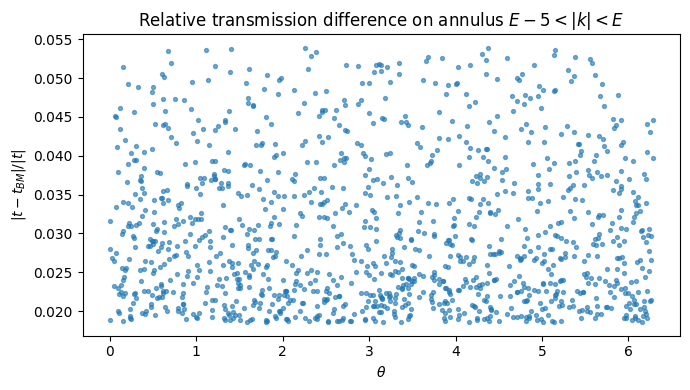

In [ ]:
# Additional sampling on annulus E-10 < |k| < E
n_ring_samples = 1200
theta_ring = np.random.uniform(0.0, 2 * np.pi, n_ring_samples)
radius_ring = np.random.uniform(E - 15.0, E - 5, n_ring_samples)
k_ring = np.column_stack(
    (radius_ring * np.cos(theta_ring), radius_ring * np.sin(theta_ring))
)

n_ring_chunks = min(6, len(k_ring))
k_ring_chunks = [
    chunk for chunk in np.array_split(k_ring, n_ring_chunks) if len(chunk) > 0
]
ring_chunk_results = Parallel(n_jobs=6, backend="loky")(
    delayed(_compute_t_chunk)(k_chunk) for k_chunk in k_ring_chunks
)

trans_amp_ring = np.concatenate([res[0] for res in ring_chunk_results])
trans_amp_ring_BM = np.concatenate([res[1] for res in ring_chunk_results])
ring_diff = np.abs(trans_amp_ring - trans_amp_ring_BM) / np.abs(trans_amp_ring)

theta_sorted_idx = np.argsort(theta_ring)
plt.figure(figsize=(7, 4))
plt.scatter(theta_ring[theta_sorted_idx], ring_diff[theta_sorted_idx], s=8, alpha=0.6)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$|t - t_{BM}|/|t|$")
plt.title(r"Relative transmission difference on annulus $E-5 < |k| < E$")
plt.tight_layout()
plt.show()

Uniformly sample the product $t(k_\parallel,E_1)t(Q_\parallel,E-E_1)$ in the region $||\vec{k}_\parallel||< 2\omega_e$

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  28 tasks      | elapsed:    0.2s
[Parallel(n_jobs=6)]: Done 1268 tasks      | elapsed:    4.8s
[Parallel(n_jobs=6)]: Done 3828 tasks      | elapsed:   13.5s
[Parallel(n_jobs=6)]: Done 7412 tasks      | elapsed:   26.4s
[Parallel(n_jobs=6)]: Done 12020 tasks      | elapsed:   42.7s
[Parallel(n_jobs=6)]: Done 17652 tasks      | elapsed:  1.1min
[Parallel(n_jobs=6)]: Done 24308 tasks      | elapsed:  1.5min
[Parallel(n_jobs=6)]: Done 31988 tasks      | elapsed:  1.9min
[Parallel(n_jobs=6)]: Done 37872 tasks      | elapsed:  2.5min
[Parallel(n_jobs=6)]: Done 42736 tasks      | elapsed:  2.8min
[Parallel(n_jobs=6)]: Done 50176 tasks      | elapsed:  3.8min
[Parallel(n_jobs=6)]: Done 56064 tasks      | elapsed:  4.2min
[Parallel(n_jobs=6)]: Done 60000 out of 60000 | elapsed:  4.5min finished


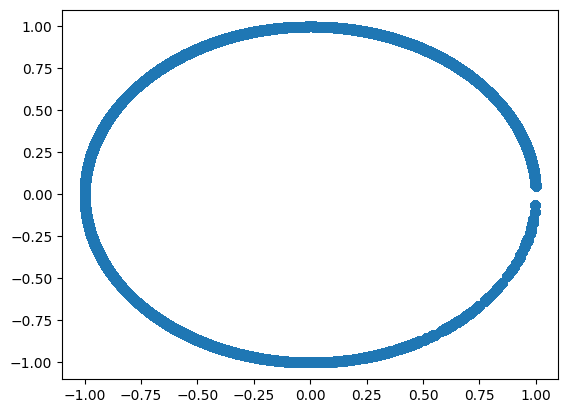

In [ ]:
from joblib import Parallel, delayed

n_samples = 60000
k_para_list = []
for i in range(0, n_samples):
    U = np.random.uniform(0, 1.0)
    theta = np.random.uniform(0, 2 * np.pi)

    kx = E * np.sqrt(U) * np.cos(theta)
    ky = E * np.sqrt(U) * np.sin(theta)
    k_para_list.append(np.array([kx, ky]))
k_para_list = np.array(k_para_list)
# print(np.shape(k_para_list))
Q_para = np.array([0.0, 0.0])
eps = 1e-3  # avoid zero-division at integration boundaries
n_energy_points = 10000
E = 2 * square_lattice.omega_e


def _sample_for_k(
    k_para: np.ndarray,
    Q_para: np.ndarray,
    E: float,
    eps: float,
    n_energy_points: int,
):
    l_para = BZ_proj(Q_para - k_para, square_lattice)
    width = E - np.linalg.norm(k_para) - np.linalg.norm(l_para)
    if width <= 0:
        return []

    E1_grid = np.linspace(
        np.linalg.norm(k_para) + eps,
        E - np.linalg.norm(l_para) - eps,
        n_energy_points,
    )
    return [
        t_reg(k_para, E1, square_lattice, sigma_func_period_numba)
        * t_reg(l_para, E - E1, square_lattice, sigma_func_period_numba)
        for E1 in E1_grid
    ]


samples_nested = Parallel(n_jobs=6, backend="loky", verbose=3)(
    delayed(_sample_for_k)(k_para, Q_para, E, eps, n_energy_points)
    for k_para in k_para_list
)
samples = np.array(
    [value for chunk in samples_nested for value in chunk], dtype=complex
)

# print(samples)
plt.scatter(samples.real, samples.imag)


[Parallel(n_jobs=9)]: Using backend ThreadingBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done  54 tasks      | elapsed:    6.6s
[Parallel(n_jobs=9)]: Done  79 out of  79 | elapsed:    6.9s finished


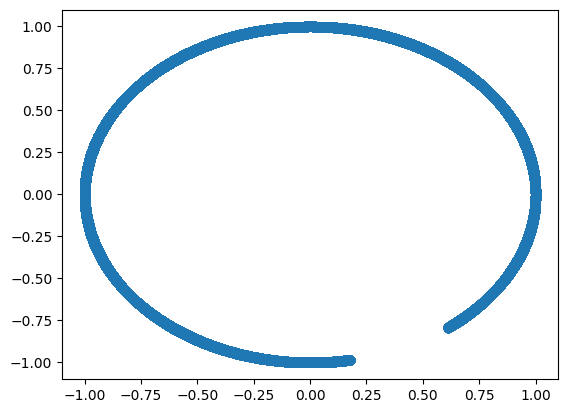

In [4]:
import os

from joblib import Parallel, delayed

n_samples = 10000
n_energy_points = 50
k_block_size = 128  # process k-grid in chunks to keep memory bounded
n_jobs = max(1, (os.cpu_count() or 1) - 1)

k_grid = np.linspace(-square_lattice.q / 2, square_lattice.q / 2, n_samples)
E = 2 * square_lattice.omega_e
Q_para = np.array([100, 100])
eps = 1e-3  # avoid poles near integration boundaries

# Shared interpolation coordinate for all valid k in one block
alpha = np.linspace(0.0, 1.0, n_energy_points)[None, :]
omega_e = square_lattice.omega_e


def _compute_block(kx_block: np.ndarray) -> np.ndarray:
    kx, ky = np.meshgrid(kx_block, k_grid, indexing="ij")
    k_para = np.column_stack((kx.ravel(), ky.ravel()))

    l_para = BZ_proj(Q_para - k_para, square_lattice)
    k_norm = np.linalg.norm(k_para, axis=1)
    l_norm = np.linalg.norm(l_para, axis=1)

    E1_start = k_norm + eps
    E1_stop = E - l_norm - eps
    valid = E1_stop > E1_start
    if not np.any(valid):
        return np.array([], dtype=np.complex128)

    k_valid = k_para[valid]
    l_valid = l_para[valid]
    E1_start = E1_start[valid]
    E1_stop = E1_stop[valid]

    # Build all E1 values in one broadcasted operation: shape (n_valid_k, n_energy_points)
    E1_grid = E1_start[:, None] + (E1_stop - E1_start)[:, None] * alpha
    E2_grid = E - E1_grid

    # sigma_func_period_numba is scalar; evaluate once per k (not per E1)
    sigma_k = np.fromiter(
        (sigma_func_period_numba(float(kx), float(ky)) for kx, ky in k_valid),
        dtype=np.complex128,
        count=k_valid.shape[0],
    )
    sigma_l = np.fromiter(
        (sigma_func_period_numba(float(lx), float(ly)) for lx, ly in l_valid),
        dtype=np.complex128,
        count=l_valid.shape[0],
    )

    t1 = (E1_grid - omega_e - np.conjugate(sigma_k)[:, None]) / (
        E1_grid - omega_e - sigma_k[:, None]
    )
    t2 = (E2_grid - omega_e - np.conjugate(sigma_l)[:, None]) / (
        E2_grid - omega_e - sigma_l[:, None]
    )
    return (t1 * t2).ravel()


n_blocks = int(np.ceil(n_samples / k_block_size))
kx_blocks = np.array_split(k_grid, n_blocks)

# Thread backend avoids expensive process pickling of large NumPy arrays.
sample_blocks = Parallel(n_jobs=n_jobs, prefer="threads", verbose=5)(
    delayed(_compute_block)(kx_block) for kx_block in kx_blocks
)
sample_blocks = [block for block in sample_blocks if block.size > 0]
samples = (
    np.concatenate(sample_blocks)
    if sample_blocks
    else np.array([], dtype=np.complex128)
)

plt.scatter(samples.real, samples.imag)
